**Disciplina: ACA052 - Meteorologia Sinótica I**

Monitor: Ronald Guiuseppi Ramírez Nina

File: Aula_05.ipynb

# **Processando dados no formato GRIB do Global Forecast System (GFS)**

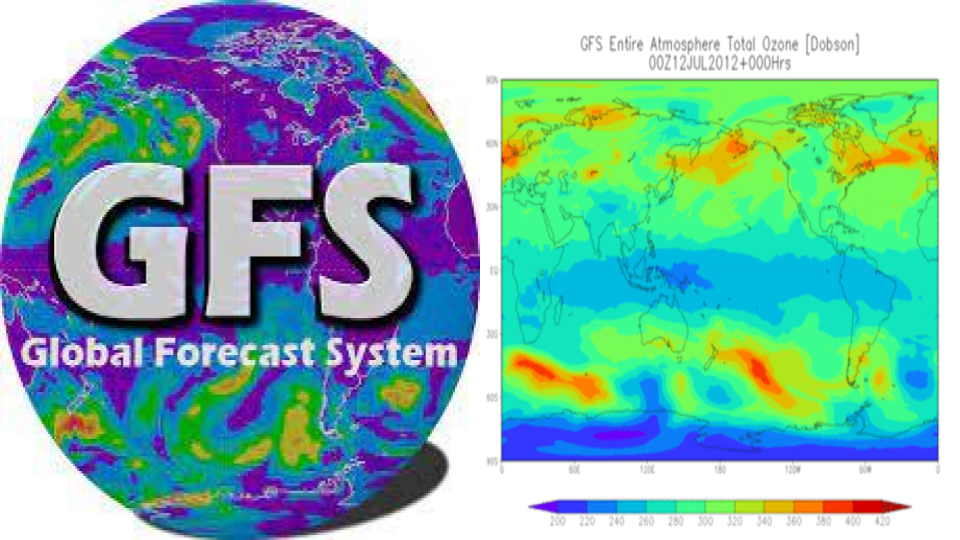

# **Instalando pacotes para o processamento dos dados grib**

In [1]:
# Instalando o cartopy, com os pacotes e versões necessárias para o seu bom funcionamento no colab
!pip uninstall -y shapely
!pip install -q netcdf4
!pip install shapely cartopy --no-binary shapely --no-binary cartopy

Found existing installation: Shapely 1.8.2
Uninstalling Shapely-1.8.2:
  Successfully uninstalled Shapely-1.8.2
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 198 kB 6.1 MB/s 
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
    Preparing wheel metadata ... done
     |████████████████████████████████| 10.8 MB 2.2 MB/s 
  Installing build dependencies ... done
  Getting requirements to build wheel ... error
     |████████████████████████████████| 10.8 MB 19.4 MB/s 
  Installing build dependencies ... done
  Getting requirements to build wheel ... error
     |████████████████████████████████| 10.8 MB 34.5 MB/s 
  Installing build dependencies ... done
  Getting requirements to build wheel ... error
     |████████████████████████████████| 12.1 MB 15.6 MB/s 
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
    Preparing wh

In [2]:
# Instalando o pacote "pygrib"
!pip install pygrib

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 16.5 MB 323 kB/s 
     |████████████████████████████████| 6.3 MB 34.6 MB/s 


# **Global Forecast Systime (GFS)**

O **GFS** é um modelo de previsão do tempo produzido pelo National Ceneters for Environmental Predition (NCEP). Os conjuntos de dados do GFS consistem em saidas ("outputs") seleccionadas do modelo como variáveis de previsão sobre uma grade. As 384 horas de previsão, com intervalos de previsão de 3 horas, são feitas com uma resolução temporal de 06 horas (i.e. atualizadas 4 vecez no dia).

O **GFS** é um modelo acoplado, composto de um modelo atmosférico, um modelo oceánico, um modelo de continente/solo, e um modelos de gelo marinho os quais trabalham juntos para proporcionar uma imagem o mais precissa possível das condições atmosféricas.  



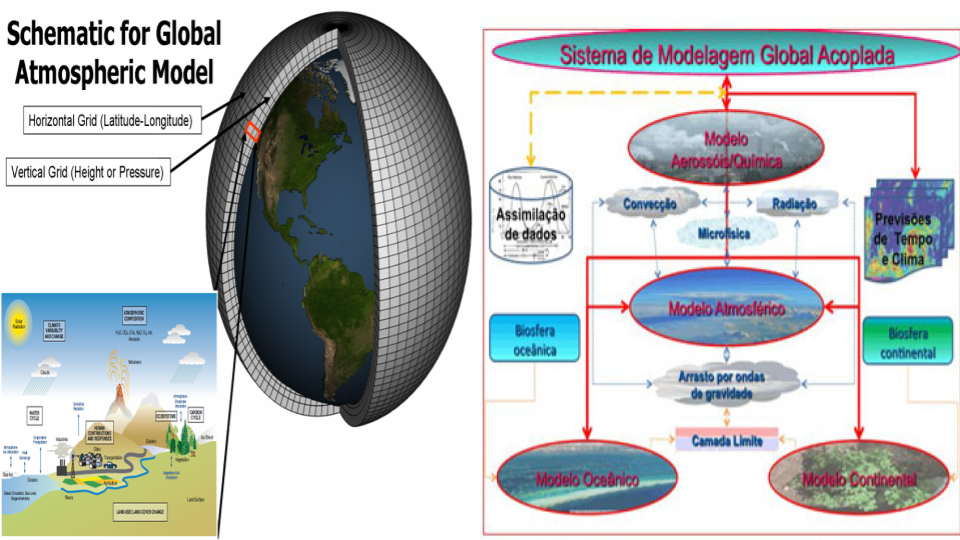

O **GFS** operacional consiste de um **sistema de assimilação de dados (GDAS)** para a atmósfera e modelos de previsão para a atmósfera e ondas oceánicas. A nova versão do GFS é o 16.0 (a anterior foi a versão 15.3). A nova versão, o **GFS 16.0** apresenta um núcleo dinâmico de volumes finitos de cubo esférico (Finite Volume Cubed Sphere - FV3) que reemplaza ao núcle dinâmico espectral. 

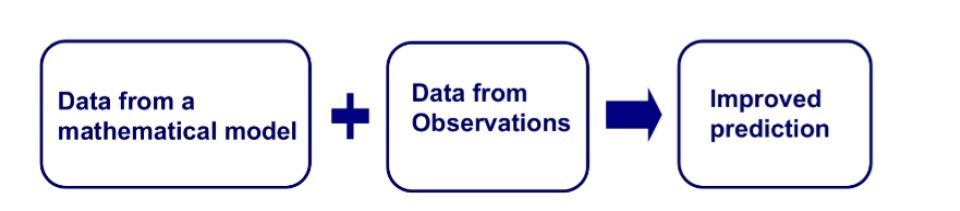

Além disso, acrescentou o número de camadas verticais de 64 (**GFS 15.3**) para 127 (**GFS 16.0**) e extendendo a parte superior do modelo desde a estratósfera (~55 km de altitude) até a mesopausa (aproximadamente 80 km de altitude). 

Os "outputs" do GFS apresentam:

- Uma resolução espacial de 0.25º X 0.25º (latitude X longitude). 

- Sua resolução temporal é de 1 hora até  as 120 horas, logo de 3 horas até os dias 5 - 16. 

- Apresenta 57 níveis verticais de pressão estándar. 

- Um ciclo de 4  vecez por dia (atualizações).

Para maiores detalhes, acessar ao seguinte link:

https://nomads.ncep.noaa.gov/txt_descriptions/GFS_doc.shtml

**Importando pacotes de processameto e geração de mapas**

In [3]:
print("1. Importar pacotes")
# Pacotes de processamento de dados 
import xarray as xr
import numpy as np
# Pacote para ler e processar dados grib
import pygrib

# Pacotes para gerar mapas
import matplotlib.pyplot as plt
import cartopy.crs as ccrs # Pacote para mapas (sistema de referência cooordenado)
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# Importar o drive para acesso aos dados
print("2. Importar drive")
from google.colab import drive
drive.mount('/content/drive')

print("3. Terminou de importar os pacotes")

1. Importar pacotes
2. Importar drive
Mounted at /content/drive
3. Terminou de importar os pacotes


**Acessando ao website do GFS para fazer o download dos dados de análise ou previsão**

O primer passo é acessar ao seguinte link:

https://nomads.ncep.noaa.gov/

Ou escrever no buscado de www.google.com o seguinte: **gfs nomads data** e fazer clic na primeira opção

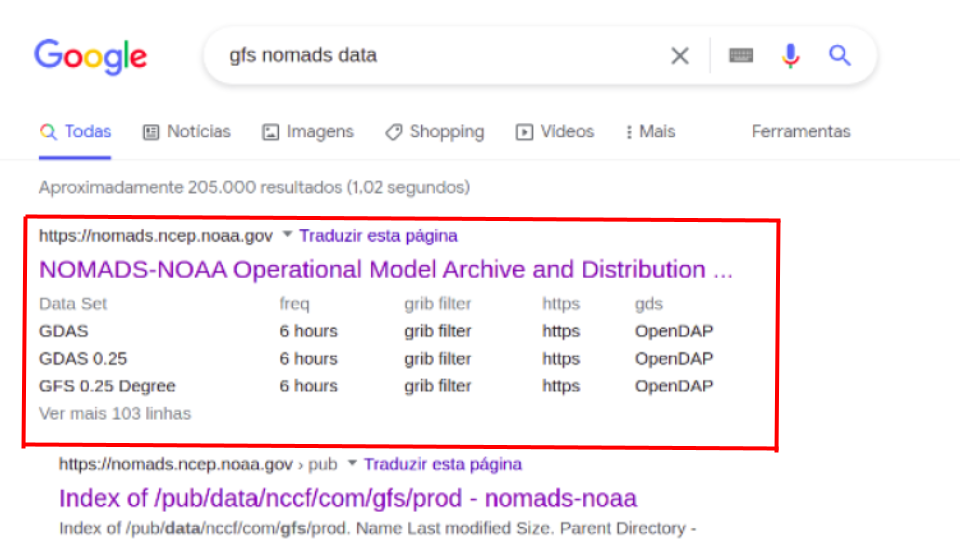

Depois de entrar ao link ou dar clic na primeira opção do site do **GFS**. Seleccionar os dados de análise ou previsão. Escolher o produto de interesse do **GFS** segundo a resolução de interesse e dar **clic** na opção **grib filter**

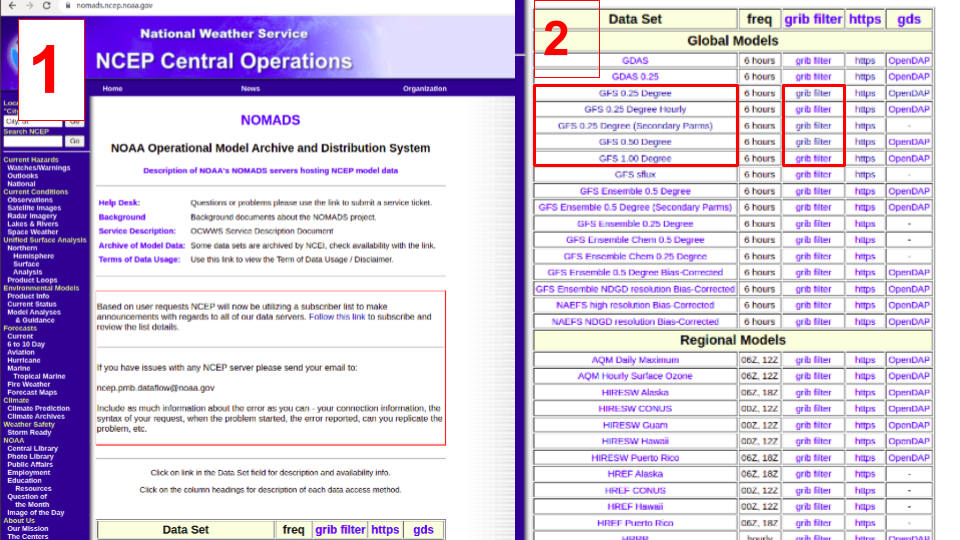

Depois de fazer clic em **grib filter**, vai aprecer as seguintes opções:

1º Fazer clic em uma data da sua escolha **gfs_20220525**.

2º Fazer clic em uma hora da sua escolha **12**

3º Fazer clic na opção **atmos**

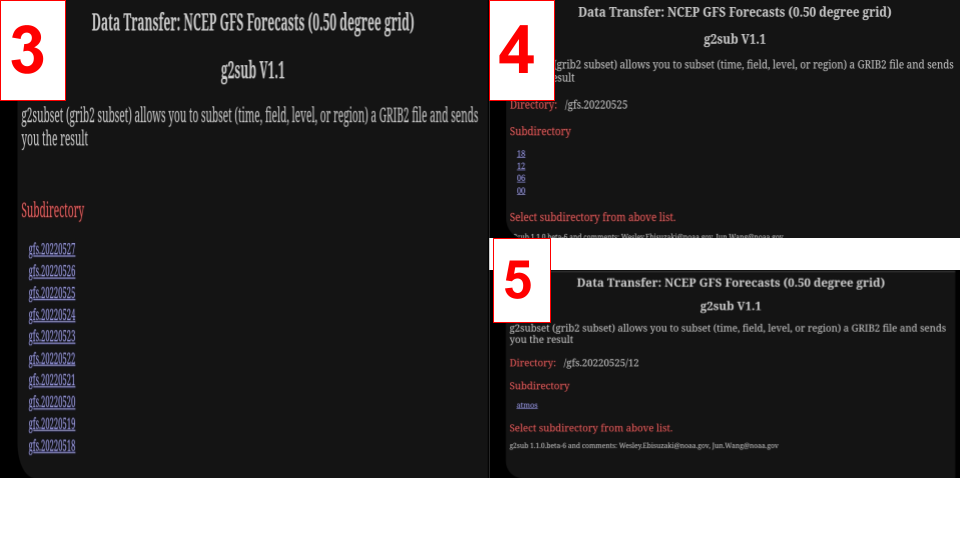

Depois de fazer esses 3 pasos, vocês acessaram ao seguinte site:

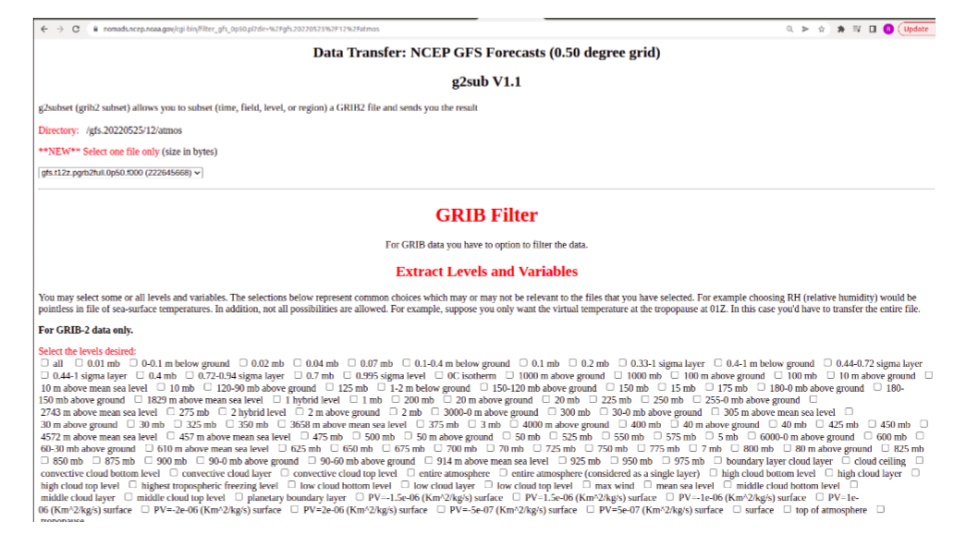

Na secção **Select the levels desired**, escolher:

- 1000mb, 200mb, 300mb, 500mb, 850mb, 925mb, 2m above ground, mean sea level, surface. 

Na seção **Select the variables desired**, escolher:

- all

Na seção **Extract Subregion**, escolher:

- Escolher a opção por default, ou seja:

left longitude: 0      right longitude: 360

top latitude: 90        bottom latitude: -90

Finalmente Fazer clic em **Start download** 

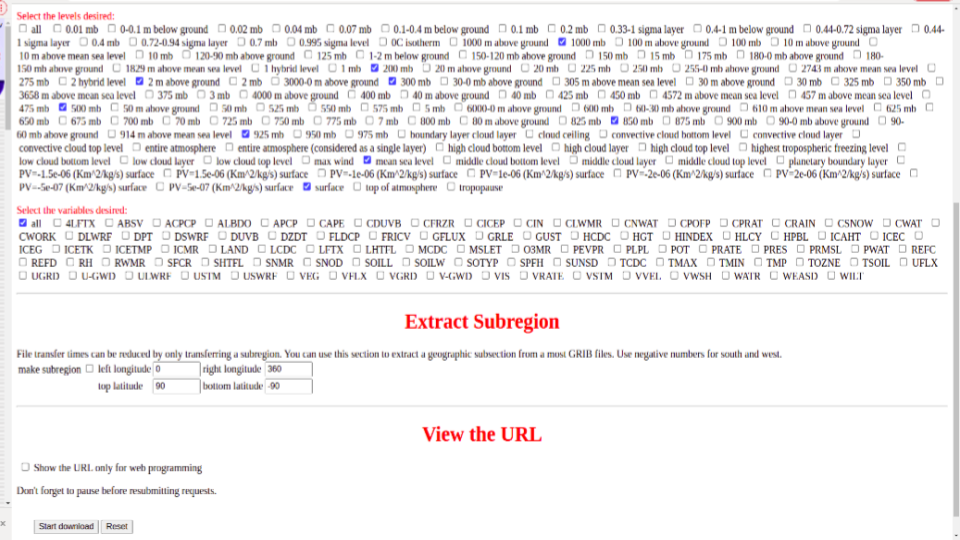

O seguinte passo é subir o file **grib** a sua pasta de trabalho do drive

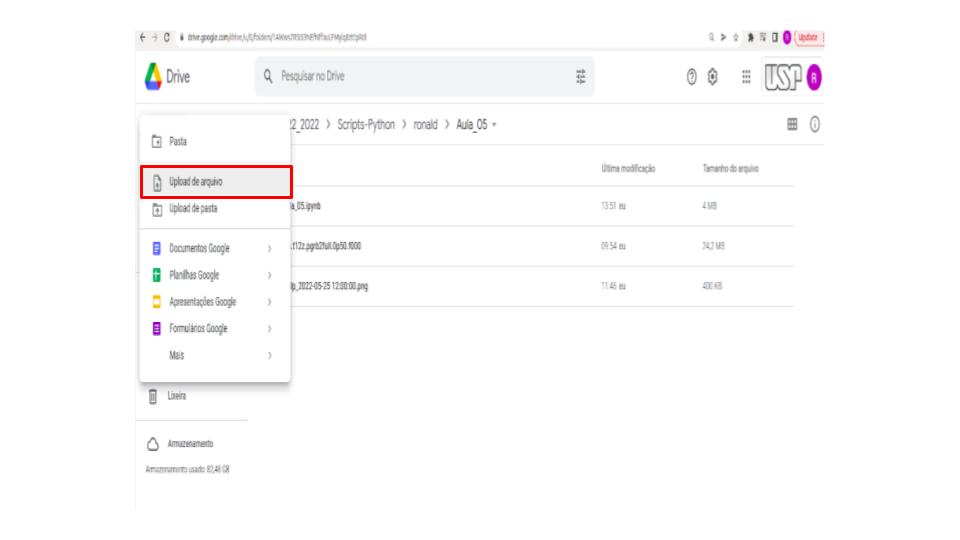

Depois seleccionar o arquivo **grib** e fazer clic em **open/abrir**

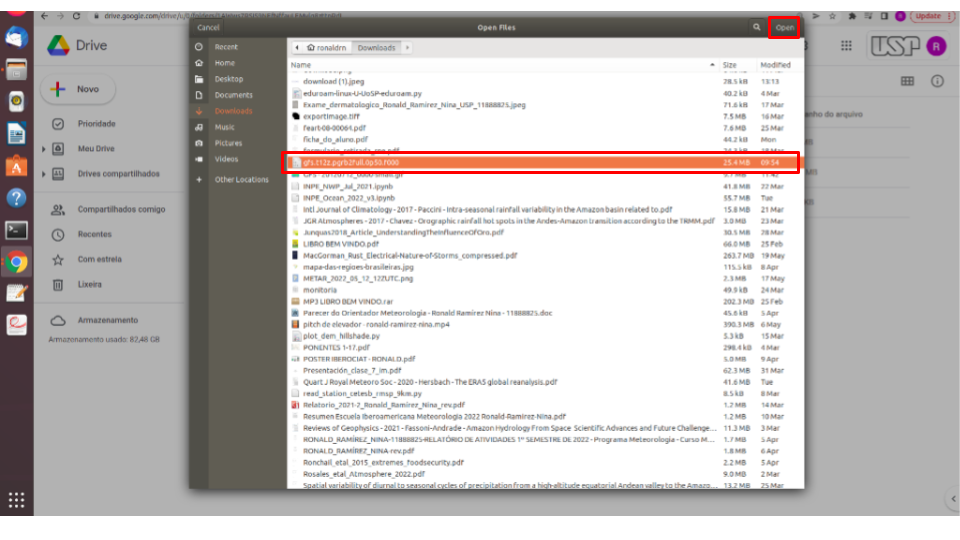

In [4]:
print("4. Ler arquivo grib")
# Salvar o path do arquivo grib em um objeto --> "path"
path = '/content/drive/Shareddrives/ACA0522_2022/Scripts-Python/ronald/Aula_05/gfs.t12z.pgrb2full.0p50.f000'
# Ler o arquivo grib 
gfs = pygrib.open(path)

# Mostrar a lista de variáveis do nosso arquivo grib
print("5. Lista de variáveis do arquivo grib")
print('                         ')
print('--------------------------------------------------------------------------------------------------')
f = open("variables.txt", "w")

for variables in gfs:
  print(variables)
  print(variables, file=f)
f.close()

4. Ler arquivo grib
5. Lista de variáveis do arquivo grib
                         
--------------------------------------------------------------------------------------------------
1:Pressure reduced to MSL:Pa (instant):regular_ll:meanSea:level 0:fcst time 0 hrs:from 202205251200
2:Visibility:m (instant):regular_ll:surface:level 0:fcst time 0 hrs:from 202205251200
3:Wind speed (gust):m s**-1 (instant):regular_ll:surface:level 0:fcst time 0 hrs:from 202205251200
4:Geopotential Height:gpm (instant):regular_ll:isobaricInhPa:level 20000 Pa:fcst time 0 hrs:from 202205251200
5:Temperature:K (instant):regular_ll:isobaricInhPa:level 20000 Pa:fcst time 0 hrs:from 202205251200
6:Relative humidity:% (instant):regular_ll:isobaricInhPa:level 20000 Pa:fcst time 0 hrs:from 202205251200
7:Total Cloud Cover:% (instant):regular_ll:isobaricInhPa:level 20000 Pa:fcst time 0 hrs:from 202205251200
8:Specific humidity:kg kg**-1 (instant):regular_ll:isobaricInhPa:level 20000 Pa:fcst time 0 hrs:from 202205251

In [5]:
# Observar os index dos níveis atmosféricos das variáveis
print("6. Observar os index segundo o nível atmosférico")
u = gfs.select(name = 'U component of wind')
u

6. Observar os index segundo o nível atmosférico


[11:U component of wind:m s**-1 (instant):regular_ll:isobaricInhPa:level 20000 Pa:fcst time 0 hrs:from 202205251200,
 27:U component of wind:m s**-1 (instant):regular_ll:isobaricInhPa:level 30000 Pa:fcst time 0 hrs:from 202205251200,
 43:U component of wind:m s**-1 (instant):regular_ll:isobaricInhPa:level 50000 Pa:fcst time 0 hrs:from 202205251200,
 59:U component of wind:m s**-1 (instant):regular_ll:isobaricInhPa:level 85000 Pa:fcst time 0 hrs:from 202205251200,
 75:U component of wind:m s**-1 (instant):regular_ll:isobaricInhPa:level 92500 Pa:fcst time 0 hrs:from 202205251200,
 91:U component of wind:m s**-1 (instant):regular_ll:isobaricInhPa:level 100000 Pa:fcst time 0 hrs:from 202205251200]

In [6]:
pressao = gfs.select(name = "Pressure reduced to MSL")
pressao

[1:Pressure reduced to MSL:Pa (instant):regular_ll:meanSea:level 0:fcst time 0 hrs:from 202205251200]

7. Seleccionar variável de interesse
8. Informação do arquivo grib
Init: 2022-05-25 12:00:00 UTC
Run: 12Z
Forecast: +0
Valid: 2022-05-25 12:00:00 UTC
9. Seleccionar a extensão do mapa
10. Ler o dado com a região específica - América do Sul
11. Configurando a figura
12. Asignar projeção ao mapa
13. Agregando linhas de costa, límites entre paises e linhas de grade
14. Agregando os estado de Brasil, The USA, e outros paises
15. Definindo intervalos para os contornos de nossa varíavel
16. Fazendo o plot da variável
17. Agregando título ao nosso mapa


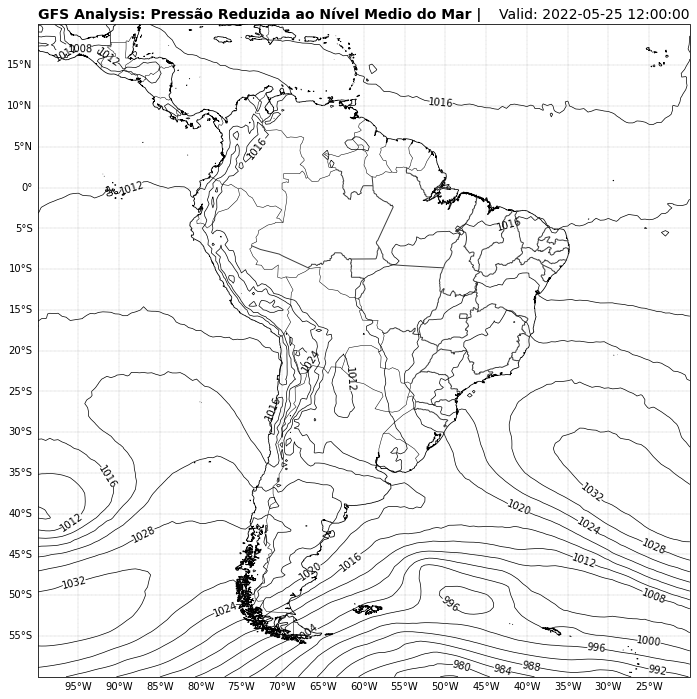

18. Salavando a figura .png


In [8]:
# Seleccionar a variável de interesse
print("7. Seleccionar variável de interesse")
# MSLP (Eta model reduction)
# Pressure reduced to MSL
mslp = gfs.select(name = 'Pressure reduced to MSL')[0]

# Obter informação do arquivo grib    
print("8. Informação do arquivo grib")
init  = str(mslp.analDate)      # Init date / time
run   = str(mslp.hour).zfill(2) # Run
ftime = str(mslp.forecastTime)  # Forecast hour
valid = str(mslp.validDate)     # Valid date / time 
print('Init: ' + init + ' UTC')
print('Run: ' + run + 'Z')
print('Forecast: +' + ftime)
print('Valid: ' + valid + ' UTC')

# Seleccionar a extensão de nosso mapa
print("9. Seleccionar a extensão do mapa")
lat_min = -60.00
lat_max = 20.00
lon_min = -100
lon_max = -20
# Extensão do mapa
extent = [lon_min, lat_min, lon_max, lat_max]

# Ler o dado com a região específica
print("10. Ler o dado com a região específica - América do Sul")
mslp, lats, lons = mslp.data(lat1 = extent[1], lat2 = extent[3], lon1 = extent[0]+360, lon2 = extent[2] + 360)

# Transformar unidades de Pa -> hPa
mslp_hpa = mslp / 100

#-----------------------------------------------------------------------------------------------------------
# Configurar o tamanho da figura (width x height, in inches)
print("11. Configurando a figura")
fig, ax = plt.subplots(figsize=(12,12), subplot_kw={'projection': ccrs.PlateCarree()})
#plt.figure(figsize=(10,10))

# Asignar una projeção ao nosso mapa
# PlateCarre() <- Projeção cilíndrica equidistante (Quase parecido ao Proj. Mercator)
print("12. Asignar projeção ao mapa")
ax = plt.axes(projection = ccrs.PlateCarree())
ax.set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

# Definir a extensão do mapa
img_extent = [extent[0], extent[2], extent[1], extent[3]]

# Fazenddo o eixo X no formato de Latitude ºW <- .xaxis.set_major_formatter()
ax.xaxis.set_major_formatter(LongitudeFormatter())
# Fazenddo o eixo Y no formato de Latitude ºS <- .yaxis.set_major_formatter()
ax.yaxis.set_major_formatter(LongitudeFormatter())

print("13. Agregando linhas de costa, límites entre paises e linhas de grade")
# Agregar linhas de costa
ax.coastlines(resolution='10m', color='black', linewidth=0.8)
# Agregar os límites entre paises
ax.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=0.5)
# Agregar linhas de grade
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='gray', alpha=1.0, linestyle='--', linewidth=0.25,\
                  xlocs=np.arange(-180, 180, 5), ylocs=np.arange(-90, 90, 5), draw_labels=True)
# Apagando as etiquetas de grade da parte sueperior
gl.top_labels = False
# Apagando as etiquetas de grade do lado direito
gl.right_labels = False

print("14. Agregando os estado de Brasil, The USA, e outros paises")
# Agregando os estados do Brasil (mas também agrega os ecb = ax.set_title('Mapa só com a opção [contourf]', size = 22)
# Lembrar da função <- .cfeature.NaturalEarthFeature()
states_provinces = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='50m',
    facecolor='none')
# Agregar os estados do Brasil No primer plot <- .add_feature()
ax.add_feature(states_provinces, edgecolor='0.25')

print("15. Definindo intervalos para os contornos de nossa varíavel")
# Definir intervalos de contorno
mslp_min = 960
mslp_max = 1050
interval = 4
levels = np.arange(mslp_min, mslp_max, interval)

print("16. Fazendo o plot da variável")
# Plot da variável
img = ax.contour(lons, lats, mslp_hpa, colors = 'black', linewidths = 0.7, levels = levels)
ax.clabel(img, inline=1, inline_spacing=0, fontsize='10',fmt = '%1.0f', colors= 'black')

print("17. Agregando título ao nosso mapa")
# Agregando titulo ao mapa
plt.title('GFS Analysis: Pressão Reduzida ao Nível Medio do Mar |' , fontweight='bold', fontsize=14, loc='left')
plt.title('Valid: ' + valid, fontsize=14, loc='right')
#----------------------------------------------------------------------------------------------------------- 

# Show the image
plt.show()

# Salvando a figura
print("18. Salavando a figura .png")
fig.savefig('/content/drive/Shareddrives/ACA0522_2022/Scripts-Python/ronald/Aula_05/mslp_' + f'{init}.png', format='png', dpi = 100)